In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import torchmetrics.functional as Fmetrics
from torch import tensor

In [ ]:
%load_ext tensorboard

In [8]:
def plot_predict(data: pd.DataFrame):
    """
    Plot prediction points gathered in prediction.csv and compute the global r².

    Parameters
    ----------
    data: pd.DataFrame
    Dataframe containing the prediction points.

    """

    # Compute R² score
    r2 = Fmetrics.regression.r2_score(tensor(data['predictions']), tensor(data['targets']), multioutput='uniform_average')
    mse = Fmetrics.regression.mean_squared_error(tensor(data['predictions']), tensor(data['targets']))
    mae = Fmetrics.regression.mean_absolute_error(tensor(data['predictions']), tensor(data['targets']))

    # Plot predictions vs targets
    plt.figure(figsize=(10, 6))
    plt.scatter(data['targets'], data['predictions'], alpha=0.5)
    plt.plot([data['targets'].min(), data['targets'].max()], [data['targets'].min(), data['targets'].max()], 'r--')
    plt.xlabel('Targets')
    plt.ylabel('Predictions')
    plt.title(f'Predictions vs Targets (R² score: {r2:.2f}, MSE: {mse:.2f}, MAE: {mae:.2f})')
    plt.axis('equal')
    plt.show()

# Inference after global training (whole dataset)

In [ ]:
%tensorboard --logdir=outputs/Africa_inf/tensorboard_logs  --host localhost

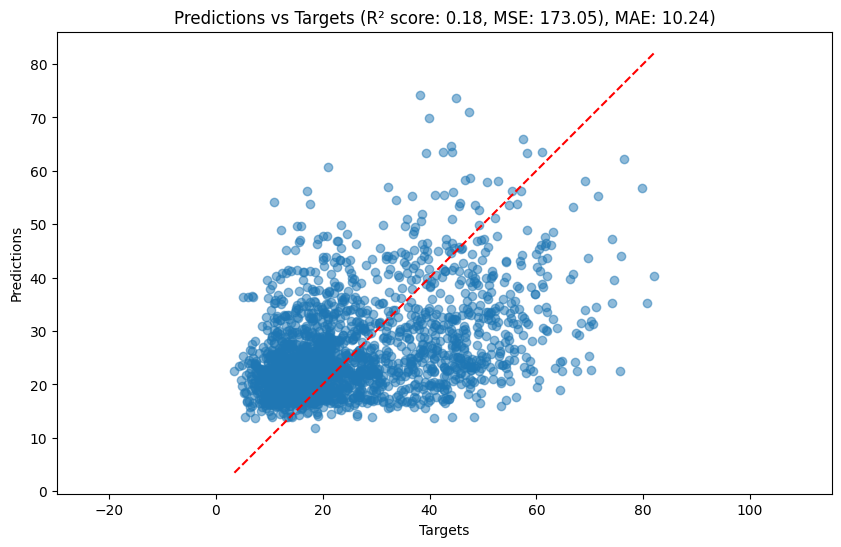

In [21]:
data = pd.read_csv(
    'predictions(1).csv')
plot_predict(data)

# Inference after global training (no Madagascar)

In [ ]:
%tensorboard --logdir=outputs/cnn_on_ms_poverty/kfolds_global_ms/tensorboard_logs/

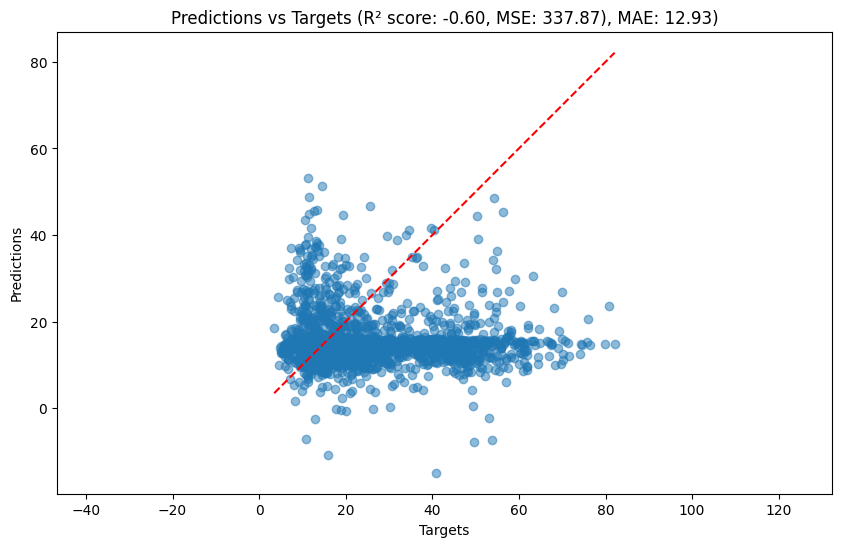

In [16]:
data = pd.read_csv('outputs/cnn_on_ms_poverty/mada_season_memmap/predictions.csv')
plot_predict(data)

# Fine-tuning on Madagascar after global training (whole dataset)

In [ ]:
%tensorboard --logdir=outputs/cnn_on_ms_poverty/kfolds_global_rgb/tensoboard_logs

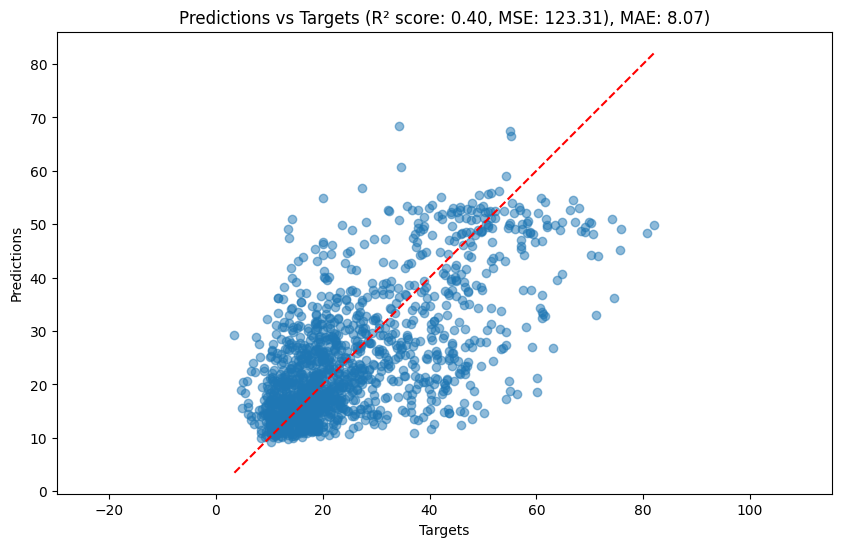

In [18]:
data = pd.read_csv('outputs/cnn_on_ms_poverty/mada_season_notrain/predictions.csv')
plot_predict(data)

# Fine-tuning on Madagascar after global training (no Madagascar)

In [ ]:
%tensorboard --logdir=outputs/cnn_on_ms_poverty/kfolds_global_rgb_imagenet/tensorboard_logs

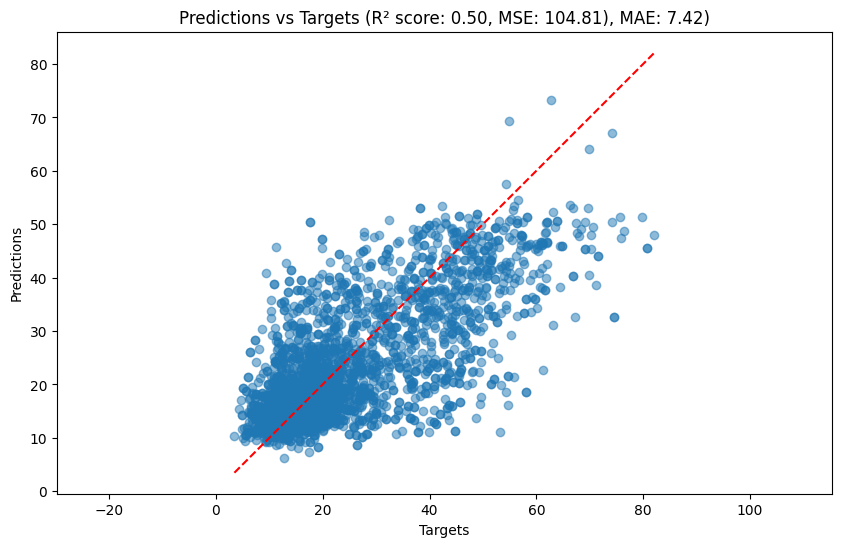

In [19]:
data = pd.read_csv('predictions_mada_old.csv')
plot_predict(data)